Código de exemplo para os classificadores.

In [4]:
#✅ 1. Carregamento e Pré-processamento

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Carregar a base (suponha que está em .csv)
df = pd.read_csv("adult.data", header=None, na_values=" ?", skipinitialspace=True)

# Adicionar nomes das colunas (base oficial)
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
           'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
           'hours-per-week', 'native-country', 'income']
df.columns = columns

# Remover linhas com valores faltantes
df.dropna(inplace=True)

# Codificar variáveis categóricas
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

# Separar features e target
X = df.drop("income", axis=1)
y = df["income"]


In [5]:
#✅ 2. Treinamento e Avaliação dos Classificadores

from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Lista de classificadores
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}


In [6]:
#✅ 3. Métricas de Avaliação com Validação Cruzada

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import numpy as np

# Função para avaliar classificadores
def avaliar_modelos(models, X, y):
    results = []

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for name, model in models.items():
        acc, prec, rec, f1, auc = [], [], [], [], []

        for train_idx, test_idx in skf.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc.append(accuracy_score(y_test, y_pred))
            prec.append(precision_score(y_test, y_pred))
            rec.append(recall_score(y_test, y_pred))
            f1.append(f1_score(y_test, y_pred))

            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(X_test)[:, 1]
                auc.append(roc_auc_score(y_test, y_prob))
            else:
                auc.append(roc_auc_score(y_test, model.decision_function(X_test)))

        results.append({
            "Classificador": name,
            "Acurácia": np.mean(acc),
            "Precisão": np.mean(prec),
            "Recall": np.mean(rec),
            "F1-score": np.mean(f1),
            "AUC-ROC": np.mean(auc)
        })

    return pd.DataFrame(results)

df_resultados = avaliar_modelos(models, X, y)
print(df_resultados)


   Classificador  Acurácia  Precisão    Recall  F1-score   AUC-ROC
0  Decision Tree  0.813243  0.609520  0.625305  0.617211  0.749136
1  Random Forest  0.858358  0.746308  0.623901  0.679616  0.906229
2            SVM  0.795215  0.976964  0.153168  0.264727  0.628914
3            KNN  0.778846  0.571235  0.325723  0.414777  0.673684


## 🔬 Testes Estatísticos de Friedman e Nemenyi

In [7]:

# ✅ Função modificada para coletar métricas por fold

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),  # probability=True necessário para AUC
    "KNN": KNeighborsClassifier()
}

def avaliar_modelos_completo(models, X, y):
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    import numpy as np

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    resultados_fold = {
        "Modelo": [],
        "Fold": [],
        "Acuracia": [],
        "Precisao": [],
        "Recall": [],
        "F1": [],
        "AUC": []
    }

    for name, model in models.items():
        for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            resultados_fold["Modelo"].append(name)
            resultados_fold["Fold"].append(fold_idx + 1)
            resultados_fold["Acuracia"].append(accuracy_score(y_test, y_pred))
            resultados_fold["Precisao"].append(precision_score(y_test, y_pred))
            resultados_fold["Recall"].append(recall_score(y_test, y_pred))
            resultados_fold["F1"].append(f1_score(y_test, y_pred))

            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(X_test)[:, 1]
            else:
                y_prob = model.decision_function(X_test)

            resultados_fold["AUC"].append(roc_auc_score(y_test, y_prob))

    return pd.DataFrame(resultados_fold)

# ✅ Avaliar modelos com resultados por fold
df_folds = avaliar_modelos_completo(models, X, y)
df_folds.head()

,Modelo,Fold,Acuracia,Precisao,Recall,F1,AUC
0,Decision Tree,1,0.818056,0.625490,0.609943,0.617619,0.747022
1,Decision Tree,2,0.812654,0.609159,0.619260,0.614168,0.746624
2,Decision Tree,3,0.807586,0.596330,0.621811,0.608804,0.744158
3,Decision Tree,4,0.813268,0.607186,0.635842,0.621184,0.752690
4,Decision Tree,5,0.811271,0.602170,0.637117,0.619151,0.751811



🔎 Teste para: Acuracia
Friedman χ² = 15.0000, p = 0.0018
➡️ Diferença significativa. Teste de Nemenyi:
Modelo         Decision Tree       KNN  Random Forest       SVM
Modelo                                                         
Decision Tree       1.000000  0.068119       0.611061  0.611061
KNN                 0.068119  1.000000       0.001363  0.611061
Random Forest       0.611061  0.001363       1.000000  0.068119
SVM                 0.611061  0.611061       0.068119  1.000000


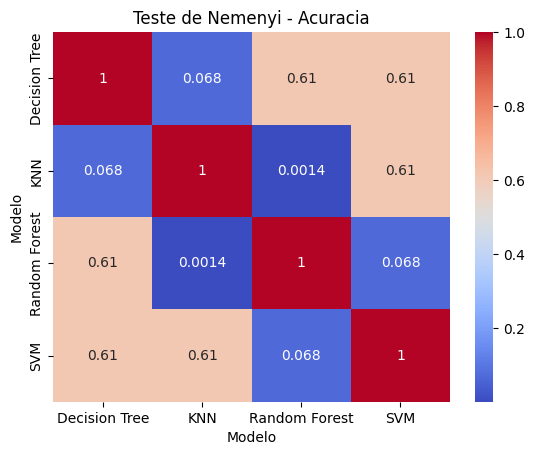


🔎 Teste para: Precisao
Friedman χ² = 15.0000, p = 0.0018
➡️ Diferença significativa. Teste de Nemenyi:
Modelo         Decision Tree       KNN  Random Forest       SVM
Modelo                                                         
Decision Tree       1.000000  0.611061       0.611061  0.068119
KNN                 0.611061  1.000000       0.068119  0.001363
Random Forest       0.611061  0.068119       1.000000  0.611061
SVM                 0.068119  0.001363       0.611061  1.000000


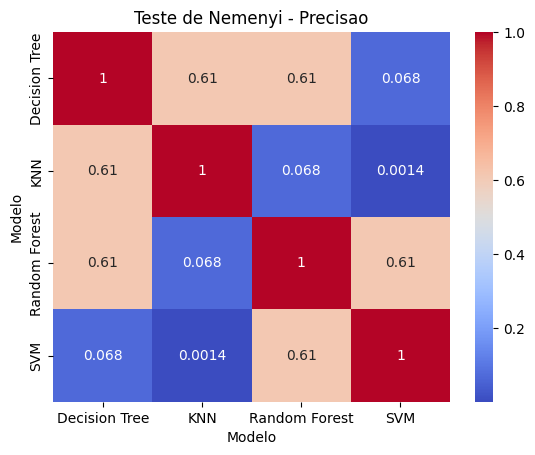


🔎 Teste para: Recall
Friedman χ² = 13.7755, p = 0.0032
➡️ Diferença significativa. Teste de Nemenyi:
Modelo         Decision Tree       KNN  Random Forest       SVM
Modelo                                                         
Decision Tree       1.000000  0.255856       1.000000  0.011804
KNN                 0.255856  1.000000       0.255856  0.611061
Random Forest       1.000000  0.255856       1.000000  0.011804
SVM                 0.011804  0.611061       0.011804  1.000000


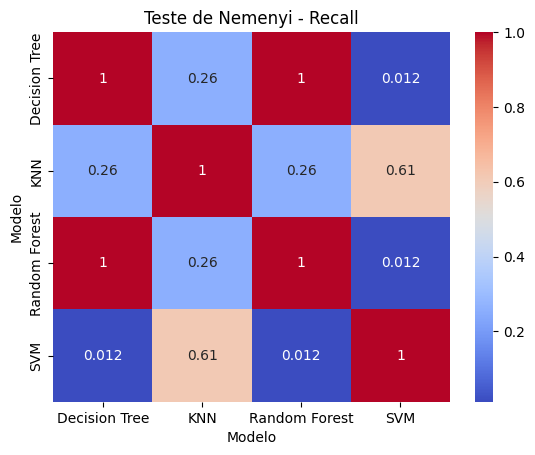


🔎 Teste para: F1
Friedman χ² = 15.0000, p = 0.0018
➡️ Diferença significativa. Teste de Nemenyi:
Modelo         Decision Tree       KNN  Random Forest       SVM
Modelo                                                         
Decision Tree       1.000000  0.611061       0.611061  0.068119
KNN                 0.611061  1.000000       0.068119  0.611061
Random Forest       0.611061  0.068119       1.000000  0.001363
SVM                 0.068119  0.611061       0.001363  1.000000


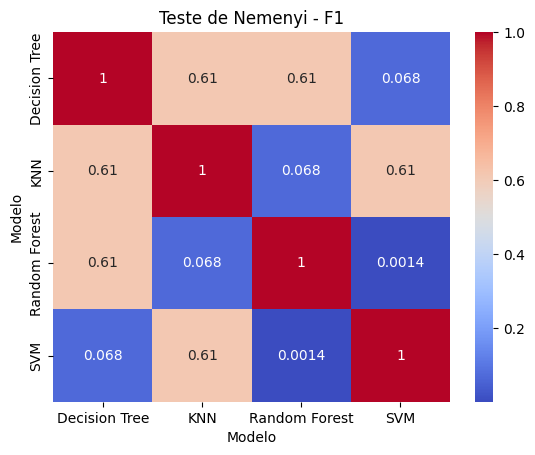


🔎 Teste para: AUC
Friedman χ² = 15.0000, p = 0.0018
➡️ Diferença significativa. Teste de Nemenyi:
Modelo         Decision Tree       KNN  Random Forest       SVM
Modelo                                                         
Decision Tree       1.000000  0.611061       0.611061  0.068119
KNN                 0.611061  1.000000       0.068119  0.611061
Random Forest       0.611061  0.068119       1.000000  0.001363
SVM                 0.068119  0.611061       0.001363  1.000000


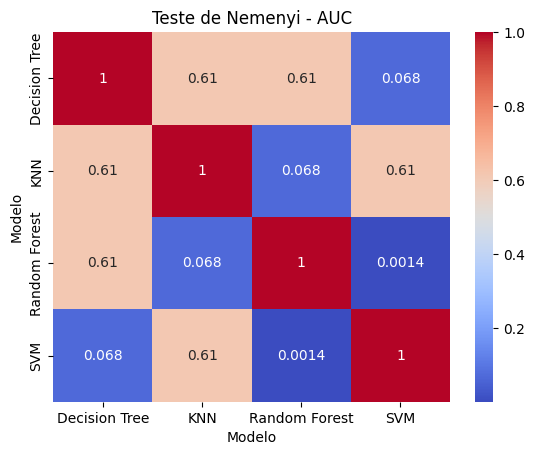

In [8]:

# ✅ Teste de Friedman e Nemenyi com visualização

import scikit_posthocs as sp
from scipy.stats import friedmanchisquare
import seaborn as sns
import matplotlib.pyplot as plt

for metrica in ["Acuracia", "Precisao", "Recall", "F1", "AUC"]:
    print(f"\n🔎 Teste para: {metrica}")
    
    df_m = df_folds.pivot(index='Fold', columns='Modelo', values=metrica)
    
    stat, p = friedmanchisquare(*[df_m[modelo] for modelo in df_m.columns])
    print(f"Friedman χ² = {stat:.4f}, p = {p:.4f}")
    
    if p < 0.05:
        print("➡️ Diferença significativa. Teste de Nemenyi:")
        nemenyi = sp.posthoc_nemenyi_friedman(df_m.values)
        nemenyi.index = df_m.columns
        nemenyi.columns = df_m.columns
        print(nemenyi)

        sns.heatmap(nemenyi, annot=True, cmap="coolwarm")
        plt.title(f"Teste de Nemenyi - {metrica}")
        plt.show()
    else:
        print("✅ Nenhuma diferença significativa entre os modelos.")


## 💾 Renomear colunas e salvar resultados por fold em CSV

In [9]:

# ✅ Renomear colunas e salvar CSV com resultados por fold

df_folds = df_folds.rename(columns={
    "Modelo": "Classificador",
    "Fold": "Dobra",
    "Acuracia": "Acurácia",
    "Precisao": "Precisão",
    "Recall": "Revocação",  # ou mantenha "Recall" se preferir
    "F1": "F1-score",
    "AUC": "AUC-ROC"
})

# Visualizar os dados renomeados
display(df_folds)

# 💾 Salvar como CSV
df_folds.to_csv("resultados_por_fold.csv", index=False)


,Classificador,Dobra,Acurácia,Precisão,Revocação,F1-score,AUC-ROC
0,Decision Tree,1,0.818056,0.625490,0.609943,0.617619,0.747022
1,Decision Tree,2,0.812654,0.609159,0.619260,0.614168,0.746624
2,Decision Tree,3,0.807586,0.596330,0.621811,0.608804,0.744158
3,Decision Tree,4,0.813268,0.607186,0.635842,0.621184,0.752690
4,Decision Tree,5,0.811271,0.602170,0.637117,0.619151,0.751811
5,Random Forest,1,0.855673,0.738077,0.621415,0.674740,0.904068
6,Random Forest,2,0.860565,0.748494,0.633929,0.686464,0.907553
7,Random Forest,3,0.857187,0.743140,0.621811,0.677083,0.905117
8,Random Forest,4,0.852733,0.730507,0.615434,0.668051,0.904438
9,Random Forest,5,0.860719,0.748683,0.634566,0.686918,0.908899
